# **Introduction**
According Unicef (2021):

* On a global scale, pneumonia claims a child's life every 39 seconds.

* The disease causes over 800,000 fatalities annually among children under five—averaging 2,200 deaths per day—including more than 153,000 newborns.

* As a primary driver of pediatric morbidity and mortality, pneumonia is responsible for more deaths in children under five than HIV/AIDS, measles, and malaria combined.

While chest X-rays are the standard diagnostic tool, accurately interpreting these images remains a difficult task even for professional radiologists.

To bridge this gap, Deep Learning (DL) has been employed to identify subtle patterns in medical imaging that may be overlooked by human experts.

By integrating AI-driven diagnostic support, medical professionals can achieve faster results, leading to more immediate treatment and significantly better patient outcomes.

# **Load data**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import shutil
import random
from pathlib import Path
import cv2
from collections import Counter
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_preprocess
import pandas as pd
import matplotlib.cm as cm
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd


In [2]:
! pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"alexpap1997","key":"2ef7a92c4921b38fe7d7731142dc29ce"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download "paultimothymooney/chest-xray-pneumonia"
!mkdir -p xray
!unzip chest-xray-pneumonia.zip -d xray

Η έξοδος ροής περικόπηκε στις τελευταίες 5000 γραμμές.
  inflating: xray/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: xray/chest_xray/train/NORMAL/IM-0446-00

In [6]:
#paths
base_dir = 'xray/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

#classes
classes = ['NORMAL', 'PNEUMONIA']

#merging all images from val to train
for class_name in classes:
    val_class_path = os.path.join(val_dir, class_name)
    train_class_path = os.path.join(train_dir, class_name)

    if os.path.exists(val_class_path):
        files = os.listdir(val_class_path)
        for file in files:
            src = os.path.join(val_class_path, file)
            dst = os.path.join(train_class_path, file)
            shutil.move(src, dst)
        print(f"Moved {len(files)} images from {class_name} (val) to {class_name} (train).")
    else:
        print(f"Path {val_class_path} does not exist (already moved?).")

#verify the merge
print("\nNew training set counts:")
for class_name in classes:
    print(f"{class_name}: {len(os.listdir(os.path.join(train_dir, class_name)))}")

Moved 8 images from NORMAL (val) to NORMAL (train).
Moved 8 images from PNEUMONIA (val) to PNEUMONIA (train).

New training set counts:
NORMAL: 1349
PNEUMONIA: 3883


In [8]:
#function that includes CLAHE + ResNet Preprocessing

def custom_resnet_preprocess(img):
    if img.dtype != 'uint8':
        img = img.astype('uint8')

    #CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    #apply the standard ResNet preprocessing
    return resnet_preprocess(final_img.astype('float32'))

#setup generator with the function
train_datagen_resnet = ImageDataGenerator(
    validation_split=0.2, #20% will be used for validation, after the merging
    preprocessing_function=custom_resnet_preprocess,
    horizontal_flip=True,
    zoom_range=0.2
)

#load data
train_generator = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.


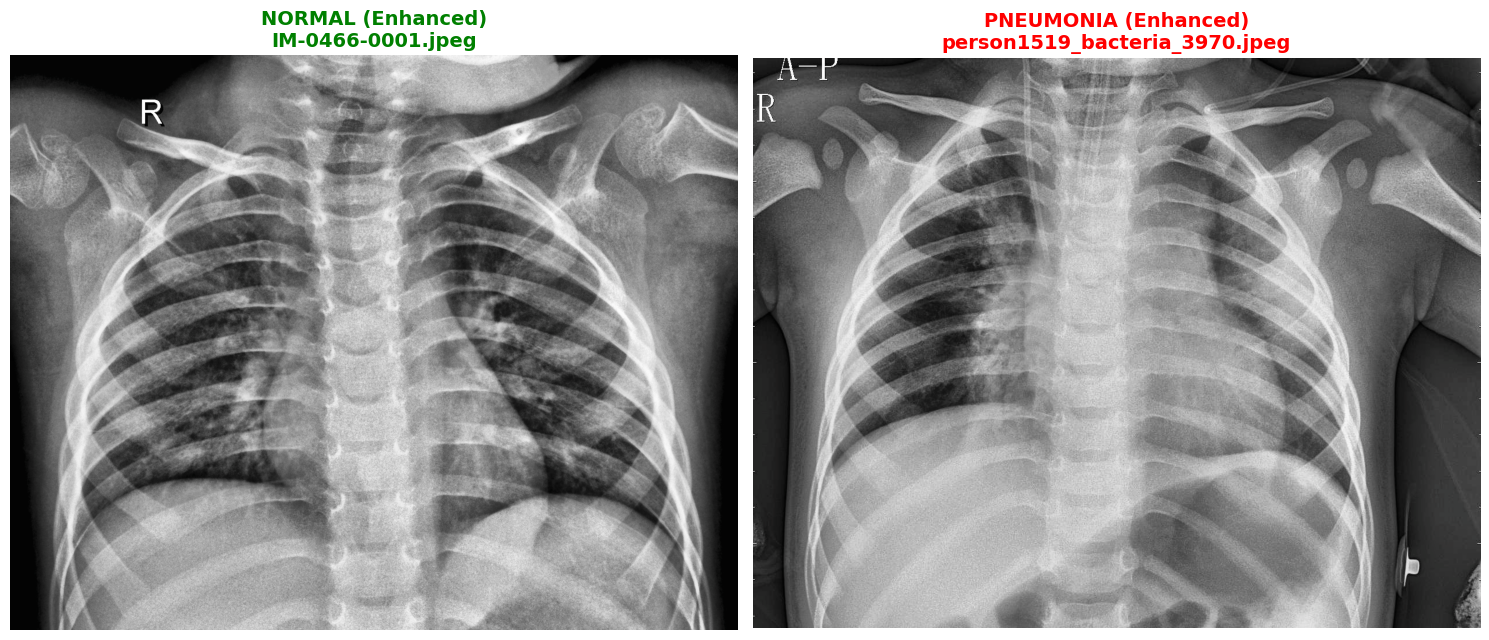

In [10]:

#paths
base_dir = 'xray/chest_xray'
pneumonia_path = os.path.join(base_dir, 'train', 'PNEUMONIA')
normal_path = os.path.join(base_dir, 'train', 'NORMAL')

#one image from each class
pneu_img_name = os.listdir(pneumonia_path)[0]
norm_img_name = os.listdir(normal_path)[0]

#load images
pneu_img = cv2.imread(os.path.join(pneumonia_path, pneu_img_name))
norm_img = cv2.imread(os.path.join(normal_path, norm_img_name))

#clahe enhancement
def apply_clahe(img):
    #convert to lab color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    #clahe to l-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    #merge and convert back to rgb
    limg = cv2.merge((cl,a,b))
    final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final


#apply clahe
pneu_final = apply_clahe(pneu_img)
norm_final = apply_clahe(norm_img)

#plot
plt.figure(figsize=(15, 7))

#normal
plt.subplot(1, 2, 1)
plt.imshow(norm_final)
plt.title(f"NORMAL (Enhanced)\n{norm_img_name}", fontsize=14, color='green', fontweight='bold')
plt.axis('off')

#pneumonia
plt.subplot(1, 2, 2)
plt.imshow(pneu_final)
plt.title(f"PNEUMONIA (Enhanced)\n{pneu_img_name}", fontsize=14, color='red', fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipython-input-287314097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = ['NORMAL', 'PNEUMONIA'],


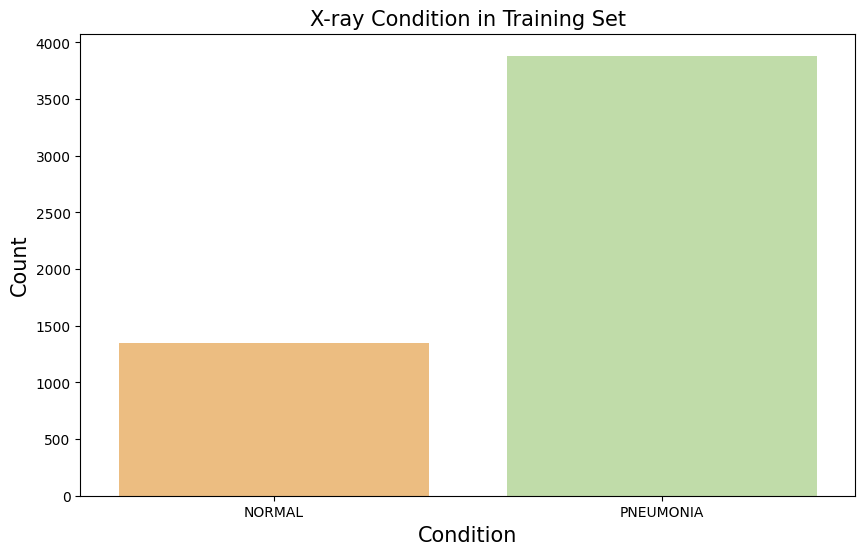

In [11]:
#plot to see how balanced is the training set
plt.figure(figsize = (10, 6))
sns.barplot(x = ['NORMAL', 'PNEUMONIA'],
            y = [len(os.listdir(normal_path)), len(os.listdir(pneumonia_path))],
            palette = 'Spectral')

plt.xlabel('Condition', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.title('X-ray Condition in Training Set', fontsize = 15)
plt.show()

In [12]:
"""
#path
kaggle_xray = 'xray/chest_xray'

dirs = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

#dirs
for d in dirs:
    for c in classes:
        path = os.path.join(kaggle_xray, d, c)
        if not os.path.isdir(path):
            print(f"File not found {path}")

print(" Kaggle dataset structure is ok\n")

#counting images
for d in dirs:
    for c in classes:
        path = os.path.join(kaggle_xray, d, c)
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.lower().endswith((".jpg",".jpeg",".png"))]
            print(f"{d} {c}: {len(files)} images")

"""

 Kaggle dataset structure is ok

train NORMAL: 1349 images
train PNEUMONIA: 3883 images
test NORMAL: 234 images
test PNEUMONIA: 390 images
val NORMAL: 0 images
val PNEUMONIA: 0 images


# **Pretrained model RESNET50**
Data augmentation


In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    validation_split=0.2,       #20% for validation
    preprocessing_function=resnet_preprocess, # normalizes data for resnet
    #augemntation
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

#train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

#validation generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.


In [16]:
#compute weights so that the model can pay more attention to the minority class
labels = train_generator.classes

class_weights_vals = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Class Weights: {class_weights}")


Class Weights: {0: np.float64(1.938425925925926), 1: np.float64(0.6738010943031864)}


Model

In [18]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False #freezing the base
#head
resnet_model = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

#compile
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='sensitivity'), #useful for medical as it minimizes false negatives
        tf.keras.metrics.AUC(name='auc')
    ]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Two phases of training

1.   Training the custom head
2.   Fine tuning



In [21]:
#callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

#phase 1
print("Starting Phase 1: Training the custom head...")
history_resnet = resnet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

#phase 2

#unfreeze the base model
base_resnet.trainable = True

#freeze all layers apart the last 30
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

#recompile with a much lower learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='sensitivity'), tf.keras.metrics.AUC(name='auc')]
)

print("\nStarting Phase 2: Fine-tuning the top layers of ResNet50...")

history_resnet_ft = resnet_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

# evaluation part
test_dir = os.path.join(base_dir, 'test')

test_generator = train_datagen_resnet.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False

print("\nFinal Test Performance:")
results = resnet_model.evaluate(test_generator)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

Starting Phase 1: Training the custom head...
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 820ms/step - accuracy: 0.8589 - auc: 0.9268 - loss: 0.3439 - sensitivity: 0.8548 - val_accuracy: 0.9081 - val_auc: 0.9808 - val_loss: 0.2147 - val_sensitivity: 0.8918 - learning_rate: 1.0000e-04
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 676ms/step - accuracy: 0.9255 - auc: 0.9784 - loss: 0.1871 - sensitivity: 0.9213 - val_accuracy: 0.9206 - val_auc: 0.9877 - val_loss: 0.2041 - val_sensitivity: 0.8995 - learning_rate: 1.0000e-04
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 674ms/step - accuracy: 0.9392 - auc: 0.9846 - loss: 0.1575 - sensitivity: 0.9350 - val_accuracy: 0.9292 - val_auc: 0.9906 - val_loss: 0.1887 - val_sensitivity: 0.9085 - learning_rate: 1.0000e-04
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 686ms/step - accuracy: 0.9421 - auc: 0.9870 - loss: 0.1439 - sensitivity: 0.9377 - val_accuracy: 0.9330 - val_auc: 0.9922 - val_loss: 0.1613 - val_sensitivity: 0.9162 - learning_rate: 1.0000e-04
E

Evaluation (confusion matrix, metrics, plots and gradcam)

Evaluating Model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 539ms/step - accuracy: 0.8054 - auc: 0.6262 - loss: 0.5921 - sensitivity: 0.6469
Generating predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 693ms/step


<Figure size 800x600 with 0 Axes>

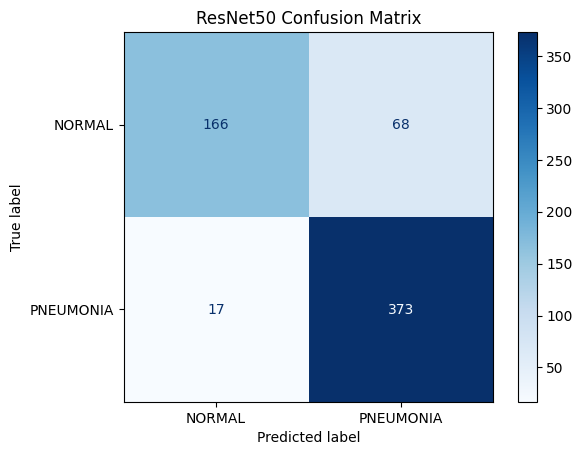

------------------------------
Accuracy     : 0.8638
Precision    : 0.8458
Recall (Sens): 0.9564
Specificity  : 0.7094
F1-score     : 0.8977
------------------------------


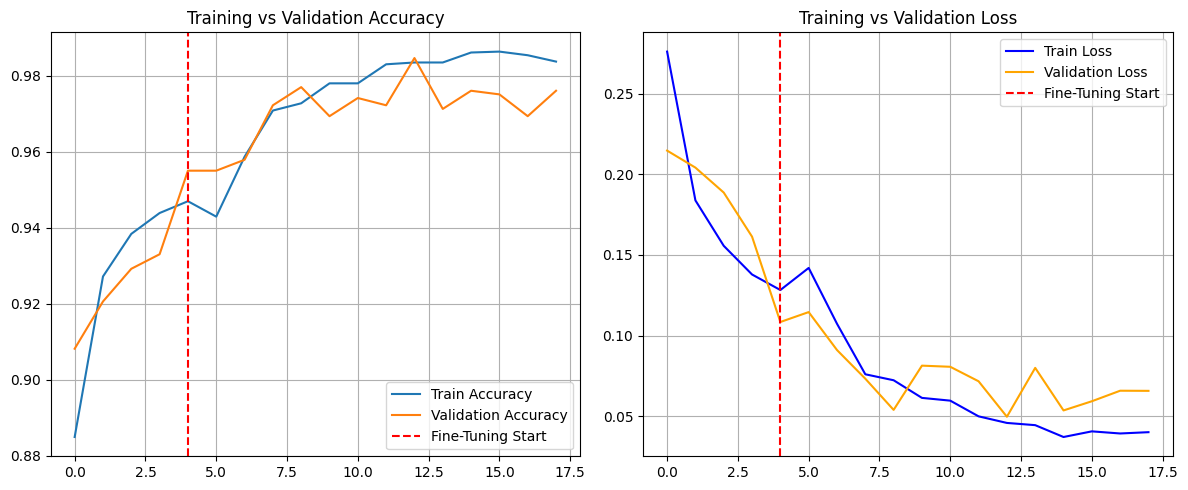

In [23]:
print("Evaluating Model...")
eval_results = resnet_model.evaluate(test_generator)

# predictions
test_generator.reset()

print("Generating predictions...")
y_probs = resnet_model.predict(test_generator, verbose=1)
y_pred = (y_probs > 0.5).astype(int).ravel()
y_true = test_generator.classes

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_generator.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("ResNet50 Confusion Matrix")
plt.show()

#metrics
tn, fp, fn, tp = cm.ravel()

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
specificity = tn / (tn + fp)

print("-" * 30)
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall (Sens): {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-score     : {f1:.4f}")
print("-" * 30)

#plots
#need to combine the 2 phases into one plot
acc = history_resnet.history['accuracy'] + history_resnet_ft.history['accuracy']
val_acc = history_resnet.history['val_accuracy'] + history_resnet_ft.history['val_accuracy']

loss = history_resnet.history['loss'] + history_resnet_ft.history['loss']
val_loss = history_resnet.history['val_loss'] + history_resnet_ft.history['val_loss']

#plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_resnet.history['accuracy'])-1, color='r', linestyle='--', label='Fine-Tuning Start')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

#plot loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(x=len(history_resnet.history['loss'])-1, color='r', linestyle='--', label='Fine-Tuning Start')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Selected File: person69_virus_129.jpeg
True Label:    PNEUMONIA
Model Pred:    PNEUMONIA (100.00% confidence)


/tmp/ipython-input-3995724815.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


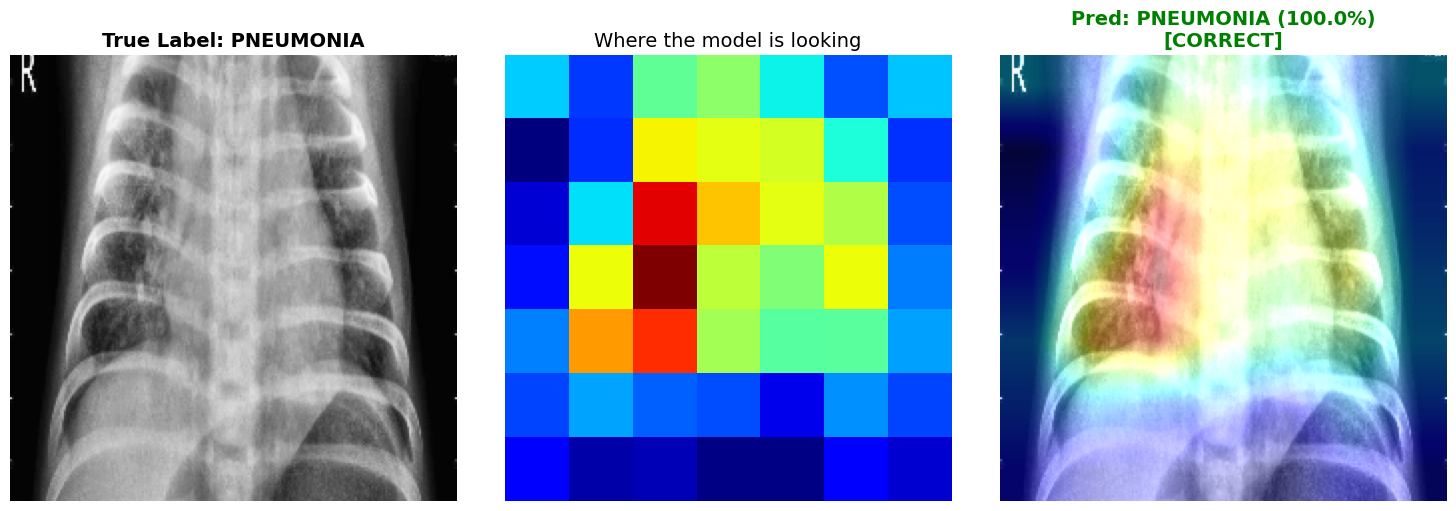

In [39]:
#Grad-CAM heatmap
def make_gradcam_heatmap(img_array, full_model, base_model_layer_index=0):
    """
    img_array: Preprocessed image batch (1, 224, 224, 3)
    full_model: Your trained 'resnet_model'
    base_model_layer_index: Index of base_resnet in the Sequential model (usually 0)
    """

    base_model = full_model.layers[base_model_layer_index]
    head_input = tf.keras.Input(shape=base_model.output_shape[1:])
    x = head_input
    for layer in full_model.layers[base_model_layer_index+1:]:
        x = layer(x)
    head_model = tf.keras.Model(head_input, x)

    #compute gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output = base_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = head_model(last_conv_layer_output)

        #the score for the "Pneumonia" clas. (since its sigmoid binary, the output is just the probability of class 1)
        score = preds[0][0]

    grads = tape.gradient(score, last_conv_layer_output)

    #global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #multiply feature map by weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    #relu
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

#  function
def get_processed_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    #clahe
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # resnet preprocessing
    from tensorflow.keras.applications.resnet50 import preprocess_input
    img_array = preprocess_input(final_img.astype('float32'))

    return np.expand_dims(img_array, axis=0), final_img

import random


#random test image (both classes)
test_dir = os.path.join(base_dir, 'test')
classes = ['NORMAL', 'PNEUMONIA']
true_label = random.choice(classes)
class_dir = os.path.join(test_dir, true_label)
img_name = random.choice(os.listdir(class_dir))
img_path = os.path.join(class_dir, img_name)

print(f"Selected File: {img_name}")
print(f"True Label:    {true_label}")
img_batch, original_enhanced_img = get_processed_image(img_path)

#model prediction
pred_prob = resnet_model.predict(img_batch, verbose=0)[0][0]
if pred_prob > 0.5:
    pred_label = "PNEUMONIA"
    confidence = pred_prob
else:
    pred_label = "NORMAL"
    confidence = 1.0 - pred_prob

print(f"Model Pred:    {pred_label} ({confidence:.2%} confidence)")

#heatmap
heatmap = make_gradcam_heatmap(img_batch, resnet_model, base_model_layer_index=0)

#plot
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_resized = cv2.resize(heatmap_uint8, (224, 224))

#color map
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

#overlay
jet_heatmap = (jet_heatmap * 255).astype("uint8")
superimposed_img = cv2.addWeighted(jet_heatmap, 0.4, original_enhanced_img, 1.0, 0)

# green color if correct, red color if wrong)
if true_label == pred_label:
    status_color = 'green'
    status_text = "CORRECT"
else:
    status_color = 'red'
    status_text = "WRONG"

#plot
plt.figure(figsize=(15, 5))

#true label
plt.subplot(1, 3, 1)
plt.imshow(original_enhanced_img)
plt.title(f"True Label: {true_label}", fontsize=14, fontweight='bold')
plt.axis('off')

#heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Where the model is looking", fontsize=14)
plt.axis('off')

#overlay with prediction result
plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Pred: {pred_label} ({confidence:.1%})\n[{status_text}]",
          fontsize=14, color=status_color, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# **Pre trained model VGG16**
Augmentation

In [40]:
function
def custom_vgg_preprocess(img):
    # clahe
    if img.dtype != 'uint8':
        img = img.astype('uint8')

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    #normalization
    return vgg_preprocess(final_img.astype('float32'))

#vgg data generator
train_datagen_vgg = ImageDataGenerator(
    validation_split=0.2,       # again 20% for val
    preprocessing_function=custom_vgg_preprocess,
    horizontal_flip=True,
    zoom_range=0.2
)

#reload the generators
print("Loading VGG Training Data...")
train_generator = train_datagen_vgg.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

print("Loading VGG Validation Data...")
val_generator = train_datagen_vgg.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Loading VGG Training Data...
Found 4187 images belonging to 2 classes.
Loading VGG Validation Data...
Found 1045 images belonging to 2 classes.


VGG16 Model
Training in to phases:


1.   Frozen base
2.   Fine tuning




In [43]:
#VGG16 model
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg.trainable = False  #freeze base

vgg_model = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='sensitivity'), tf.keras.metrics.AUC(name='auc')]
)

#phase 1
print("Starting VGG Phase 1: Training Custom Head...")
history_vgg = vgg_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
)

#phase 2
print("\nStarting VGG Phase 2: Fine-Tuning...")

base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:
    layer.trainable = False

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # low LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='sensitivity'), tf.keras.metrics.AUC(name='auc')]
)

history_vgg_ft = vgg_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
)

Starting VGG Phase 1: Training Custom Head...
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 803ms/step - accuracy: 0.6184 - auc: 0.6902 - loss: 1.7003 - sensitivity: 0.6046 - val_accuracy: 0.9110 - val_auc: 0.9748 - val_loss: 0.2426 - val_sensitivity: 0.9046 - learning_rate: 1.0000e-04
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 751ms/step - accuracy: 0.8265 - auc: 0.9035 - loss: 0.6014 - sensitivity: 0.8227 - val_accuracy: 0.9072 - val_auc: 0.9844 - val_loss: 0.2644 - val_sensitivity: 0.8776 - learning_rate: 1.0000e-04
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 747ms/step - accuracy: 0.8750 - auc: 0.9430 - loss: 0.4035 - sensitivity: 0.8766 - val_accuracy: 0.9359 - val_auc: 0.9838 - val_loss: 0.1778 - val_sensitivity: 0.9369 - learning_rate: 1.0000e-04
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 756ms/step - accuracy: 0.8898 - auc: 0.9559 - loss: 0.3154 - sensitivity: 0.8880 - val_accuracy: 0.9330 - val_auc: 0.9865 - val_loss: 0.1919 - val_sensitivity: 0.9162 - learning_rate: 1.0000e-04
E

Evaluation (confusion matrix, metrics, plots and grad-cam)

Found 624 images belonging to 2 classes.
Evaluating VGG16 Model...
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 739ms/step - accuracy: 0.7120 - auc: 0.6301 - loss: 1.1232 - sensitivity: 0.6611
Generating Predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 545ms/step


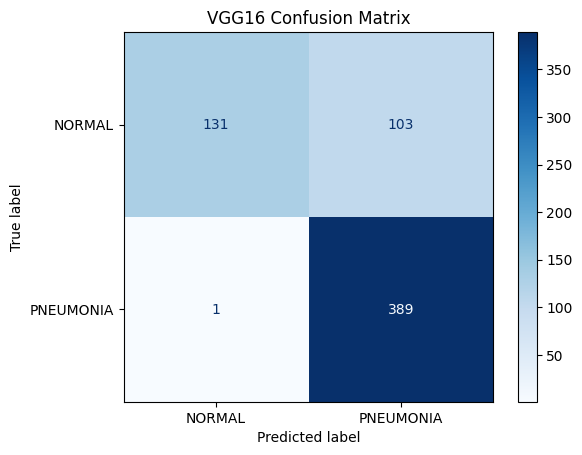

------------------------------
Accuracy     : 0.8333
Precision    : 0.7907
Recall (Sens): 0.9974
Specificity  : 0.5598
F1-score     : 0.8821
------------------------------


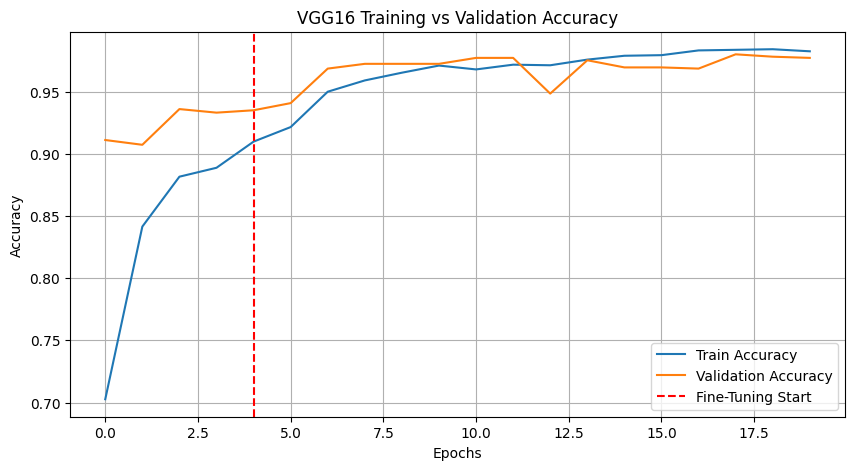

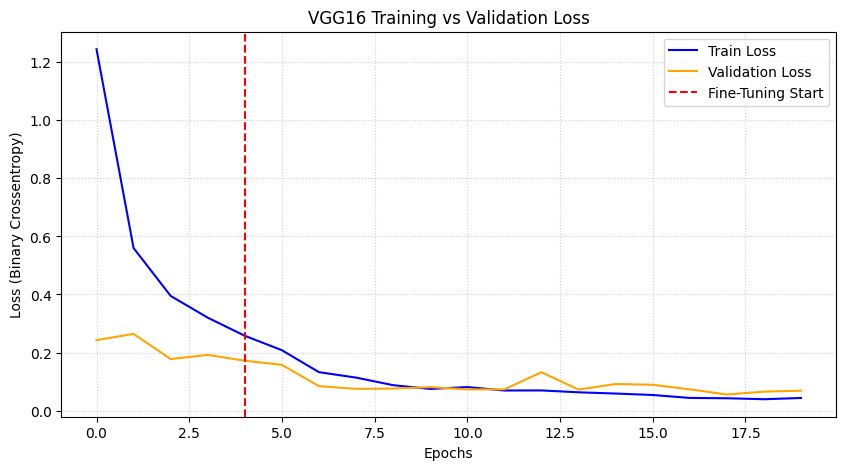

In [44]:
test_dir = os.path.join(base_dir, 'test')

test_vgg = train_datagen_vgg.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_vgg.reset()
#evaluation
print("Evaluating VGG16 Model...")
eval_results = vgg_model.evaluate(test_vgg)

#predictions
print("Generating Predictions...")
y_probs = vgg_model.predict(test_vgg, verbose=1)
y_pred = (y_probs > 0.5).astype(int).ravel()

#true labels
y_true = test_vgg.classes

#confusion matrix
cm = confusion_matrix(y_true, y_pred)

#plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(test_vgg.class_indices.keys())
)
disp.plot(cmap=plt.cm.Blues)
plt.title("VGG16 Confusion Matrix")
plt.show()

#metrics
tn, fp, fn, tp = cm.ravel()

accuracy     = accuracy_score(y_true, y_pred)
precision    = precision_score(y_true, y_pred)
recall       = recall_score(y_true, y_pred)
f1           = f1_score(y_true, y_pred)
specificity  = tn / (tn + fp)

print("-" * 30)
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall (Sens): {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-score     : {f1:.4f}")
print("-" * 30)

#need to combine phase 1 and 2 in the same plot
acc = history_vgg.history['accuracy'] + history_vgg_ft.history['accuracy']
val_acc = history_vgg.history['val_accuracy'] + history_vgg_ft.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

#line where fine-tuning started
plt.axvline(
    x=len(history_vgg.history['accuracy'])-1,
    color='r',
    linestyle='--',
    label='Fine-Tuning Start'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('VGG16 Training vs Validation Accuracy')
plt.grid(True)
plt.show()


#combined loss plot
loss = history_vgg.history['loss'] + history_vgg_ft.history['loss']
val_loss = history_vgg.history['val_loss'] + history_vgg_ft.history['val_loss']

plt.figure(figsize=(10, 5))
plt.plot(loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

plt.axvline(
    x=len(history_vgg.history['loss'])-1,
    color='r',
    linestyle='--',
    label='Fine-Tuning Start'
)

plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.title('VGG16 Training vs Validation Loss')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Selected File: NORMAL2-IM-0366-0001.jpeg
True Label:    NORMAL
VGG Prediction: NORMAL (99.94% confidence)


/tmp/ipython-input-2183570991.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


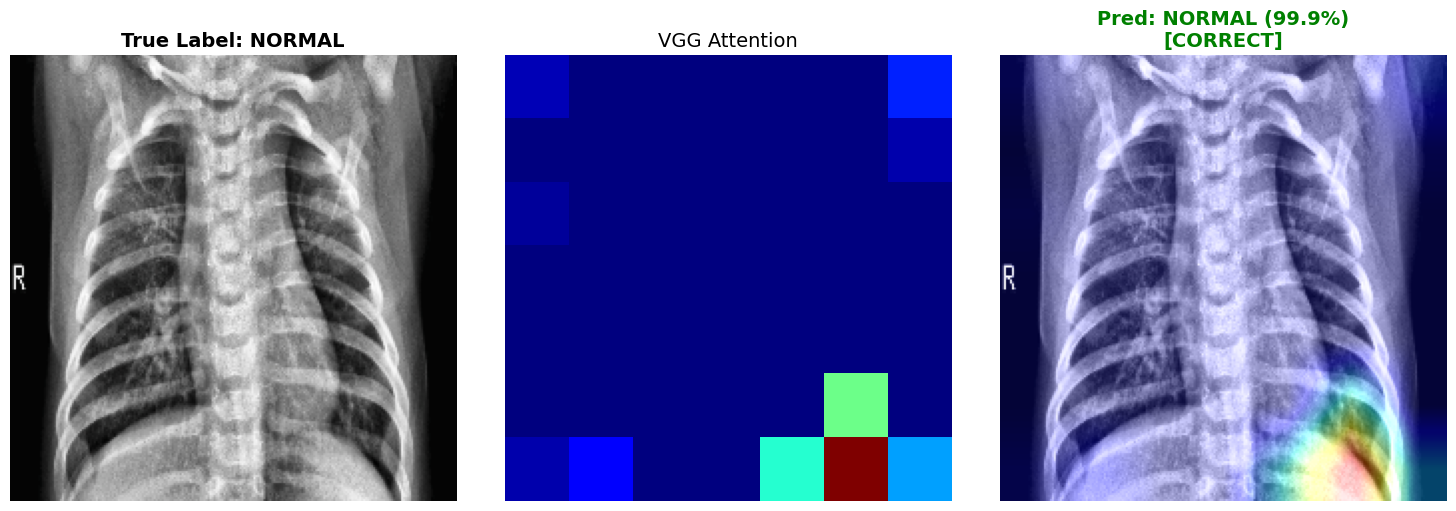

In [59]:
#function of grad-cam
def make_gradcam_heatmap(img_array, full_model, base_model_layer_index=0):
    """
    img_array: Preprocessed image batch (1, 224, 224, 3)
    full_model: Your trained 'vgg_model'
    base_model_layer_index: Index of base_vgg in the Sequential model (usually 0)
    """

    base_model = full_model.layers[base_model_layer_index]
    head_input = tf.keras.Input(shape=base_model.output_shape[1:])
    x = head_input
    for layer in full_model.layers[base_model_layer_index+1:]:
        x = layer(x)
    head_model = tf.keras.Model(head_input, x)

    #compute gradients
    with tf.GradientTape() as tape:
        #pass image through base model to get feature map
        last_conv_layer_output = base_model(img_array)
        tape.watch(last_conv_layer_output)

        #pass feature map through head model to get prediction
        preds = head_model(last_conv_layer_output)
        score = preds[0][0] # probability of pneumonia

    #calculate gradient of the score w.r.t. the feature map
    grads = tape.gradient(score, last_conv_layer_output)

    #global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #multiply feature map by weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    #relu and normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()


#function to load and enhance image

def get_vgg_processed_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    #clahe
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # VGG preprocessing
    img_array = vgg_preprocess(final_img.astype('float32'))

    return np.expand_dims(img_array, axis=0), final_img

#random image
test_dir = os.path.join(base_dir, 'test')
classes = ['NORMAL', 'PNEUMONIA']
true_label = random.choice(classes)
class_dir = os.path.join(test_dir, true_label)
img_name = random.choice(os.listdir(class_dir))
img_path = os.path.join(class_dir, img_name)

print(f"Selected File: {img_name}")
print(f"True Label:    {true_label}")

img_batch, original_enhanced_img = get_vgg_processed_image(img_path)
pred_prob = vgg_model.predict(img_batch, verbose=0)[0][0]

if pred_prob > 0.5:
    pred_label = "PNEUMONIA"
    confidence = pred_prob
else:
    pred_label = "NORMAL"
    confidence = 1.0 - pred_prob

print(f"VGG Prediction: {pred_label} ({confidence:.2%} confidence)")

#generate Heatmap
heatmap = make_gradcam_heatmap(img_batch, vgg_model, base_model_layer_index=0)

#plot
#rescale
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_resized = cv2.resize(heatmap_uint8, (224, 224))

#jet color map
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

#overlay
jet_heatmap = (jet_heatmap * 255).astype("uint8")
superimposed_img = cv2.addWeighted(jet_heatmap, 0.4, original_enhanced_img, 1.0, 0)

#color
if true_label == pred_label:
    status_color = 'green'
    status_text = "CORRECT"
else:
    status_color = 'red'
    status_text = "WRONG"

#plots
plt.figure(figsize=(15, 5))

#original
plt.subplot(1, 3, 1)
plt.imshow(original_enhanced_img)
plt.title(f"True Label: {true_label}", fontsize=14, fontweight='bold')
plt.axis('off')

#heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("VGG Attention", fontsize=14)
plt.axis('off')

#overlay
plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Pred: {pred_label} ({confidence:.1%})\n[{status_text}]",
          fontsize=14, color=status_color, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

# **Comparison of models**

Generating predictions for ResNet50...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 540ms/step
Generating predictions for VGG16...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step

--- Final Comparison Table ---


,Model,Accuracy,Sensitivity (Recall),Specificity,F1-Score,Precision
0,ResNet50,0.839744,0.935897,0.679487,0.879518,0.829545
1,VGG16,0.822115,0.989744,0.542735,0.874292,0.782961


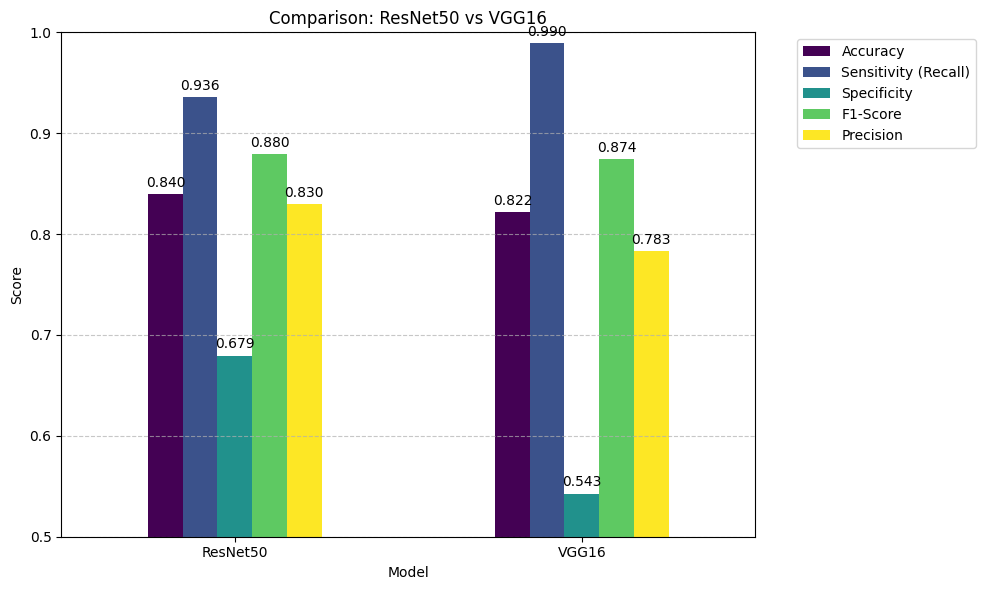

In [61]:
# comparison function
def get_metrics(model, generator, name):
    #reset generator
    generator.reset()

    #true labels and Ppedictions
    y_true = generator.classes
    print(f"Generating predictions for {name}...")
    y_probs = model.predict(generator, verbose=1)
    y_pred = (y_probs > 0.5).astype(int).ravel()

    # calculate metrics
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    #specificity calculation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)

    return {
        "Model": name,
        "Accuracy": acc,
        "Sensitivity (Recall)": recall,
        "Specificity": spec,
        "F1-Score": f1,
        "Precision": prec
    }

#metrics for resnet50
metrics_res = get_metrics(resnet_model, test_generator, "ResNet50")

#metrics for vgg16
metrics_vgg = get_metrics(vgg_model, test_vgg, "VGG16")

#plots
#dataframe
df_comparison = pd.DataFrame([metrics_res, metrics_vgg])

#display table
print("\n Final Comparison Table")
try:
    display(df_comparison)
except NameError:
    print(df_comparison)

#plot bar chart
ax = df_comparison.set_index("Model").plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Comparison: ResNet50 vs VGG16")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

Generating ResNet50 predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step
Generating VGG16 predictions...
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 534ms/step


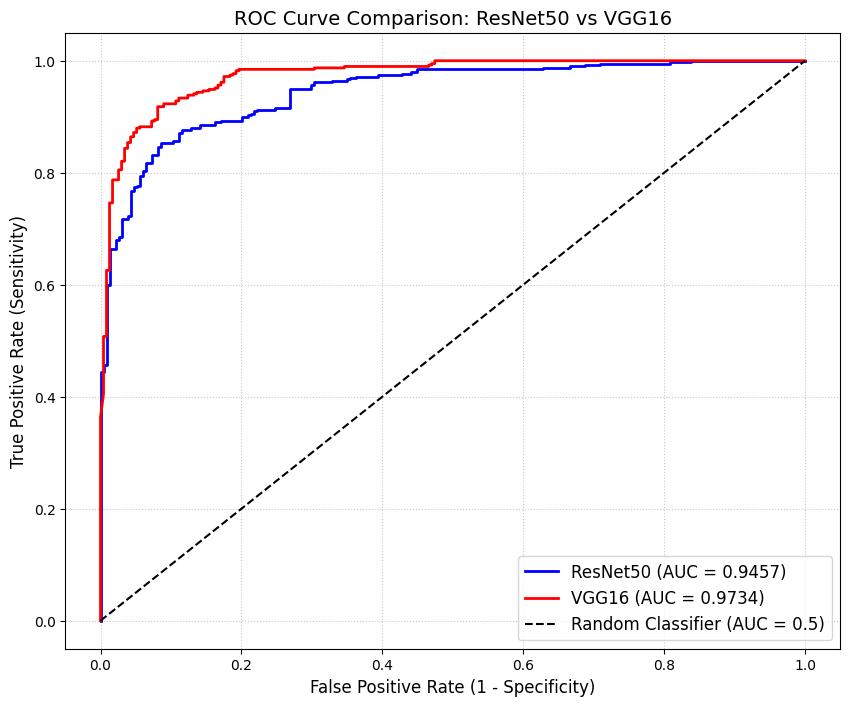

In [63]:
#prediction

#resnet50
print("Generating ResNet50 predictions...")
test_generator.reset()
y_probs_resnet = resnet_model.predict(test_generator, verbose=1).flatten()
y_true_resnet = test_generator.classes

#vgg16
print("Generating VGG16 predictions...")
test_vgg.reset()
y_probs_vgg = vgg_model.predict(test_vgg, verbose=1).flatten()
y_true_vgg = test_vgg.classes

# roc data
#resnet50
fpr_resnet, tpr_resnet, _ = roc_curve(y_true_resnet, y_probs_resnet)
auc_resnet = roc_auc_score(y_true_resnet, y_probs_resnet)
#vgg16
fpr_vgg, tpr_vgg, _ = roc_curve(y_true_vgg, y_probs_vgg)
auc_vgg = roc_auc_score(y_true_vgg, y_probs_vgg)

#plots
plt.figure(figsize=(10, 8))

#plot resnet
plt.plot(fpr_resnet, tpr_resnet, label=f'ResNet50 (AUC = {auc_resnet:.4f})', color='blue', lw=2)

#plot vgg
plt.plot(fpr_vgg, tpr_vgg, label=f'VGG16 (AUC = {auc_vgg:.4f})', color='red', lw=2)

#plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

#formatting
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: ResNet50 vs VGG16', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()